## Actuarial Insurance Portfolio Modeling Project

This project simulates the operations of a fictional insurance company.

My goal is to use historical policy and claims data to perform several common actuarial tasks, including:

- Claim frequency and severity analysis
- Insurance pricing
- Plan-level pricing
- Reserve estimation
- Reinsurance analysis
- Profitability analysis
- Future loss forecasting

All data used in this project are randomly generated.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# Use a fixed random seed so the simulated data are reproducible
np.random.seed(2026)

This section creates a fictional portfolio of insurance policies that will be used to generate and analyze claims.

In [2]:
# Set the total number of insurance policies in the portfolio.
n_policies = 10000

# Create a table containing a unique ID and plan for each policy.
policies = pd.DataFrame({
    "Policy_ID": range(1, n_policies + 1),

    "Plan": np.random.choice(
        ["Basic", "Standard", "Premium"],
        size=n_policies,
        p=[0.50, 0.35, 0.15]
    )
})

# Display the first five policies.
policies.head()

,Policy_ID,Plan
0,1,Basic
1,2,Basic
2,3,Premium
3,4,Basic
4,5,Basic


This section generates 1,000 historical claims, assigns each claim to a policy, and models different expected claim severities for the Basic, Standard, and Premium plans.

In [3]:
# Set the total number of claims.
n_claims = 1000

# Randomly select which policy each claim belongs to.
# replace=True allows the same policy to have more than one claim.
claim_policy_ids = np.random.choice(
    policies["Policy_ID"],
    size=n_claims,
    replace=True
)

# Look up the insurance plan associated with each selected policy.
claim_plans = policies.set_index("Policy_ID").loc[
    claim_policy_ids,
    "Plan"
].values

# Assign a different lognormal mean to each plan.
# Basic is expected to have lower claim severity,
# Standard is in the middle,
# and Premium is expected to have higher claim severity.
plan_means = {
    "Basic": 7.8,
    "Standard": 8.0,
    "Premium": 8.2
}

# Generate claim amounts based on the plan associated with each claim.
claim_amounts = np.array([
    np.random.lognormal(
        mean=plan_means[plan],
        sigma=1
    )
    for plan in claim_plans
])

# Create the claims table.
claims = pd.DataFrame({
    "Claim_ID": range(1, n_claims + 1),
    "Policy_ID": claim_policy_ids,
    "Claim_Amount": claim_amounts
})

# Add each policy's plan to the claims table.
claims = claims.merge(
    policies,
    on="Policy_ID",
    how="left"
)

# Display the first five claims.
claims.head()

,Claim_ID,Policy_ID,Claim_Amount,Plan
0,1,8456,481.907939,Standard
1,2,8126,1190.598967,Premium
2,3,2400,6181.633855,Standard
3,4,9859,2186.312730,Standard
4,5,5386,4397.380375,Standard


This section summarizes the simulated claim amounts so we can understand their size and distribution before using them in actuarial calculations.

In [4]:
# Display summary statistics for the claim amounts.
claims["Claim_Amount"].describe()

count     1000.000000
mean      4742.177976
std       6180.631553
min        134.471832
25%       1480.716869
50%       2820.776310
75%       5882.976506
max      59564.730904
Name: Claim_Amount, dtype: float64

This section displays the distribution of simulated claim amounts to examine the shape of the loss data.

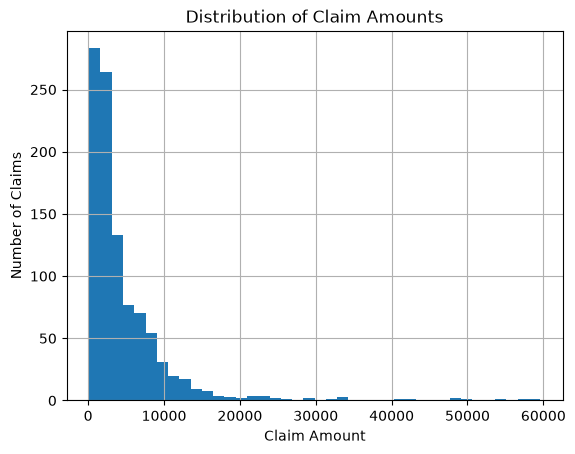

In [5]:
# Create a histogram of the simulated claim amounts.
claims["Claim_Amount"].hist(bins=40)

# Add a title to the chart.
plt.title("Distribution of Claim Amounts")

# Label the horizontal axis.
plt.xlabel("Claim Amount")

# Label the vertical axis.
plt.ylabel("Number of Claims")

# Display the chart.
plt.show()

The claim amounts are right-skewed, so this section applies a natural logarithm transformation to see whether the data become more normally distributed.

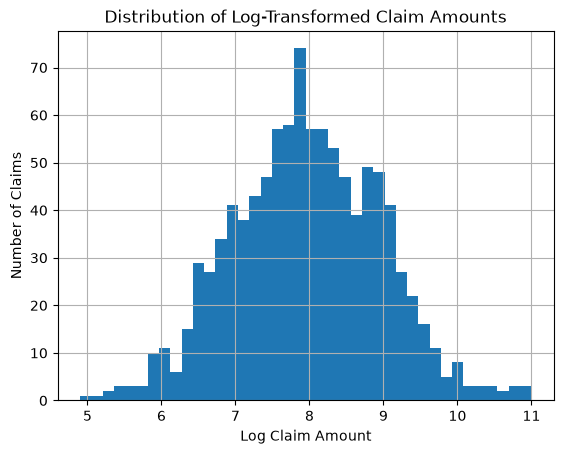

In [6]:
# Take the natural logarithm of each claim amount.
log_claim_amounts = np.log(claims["Claim_Amount"])

# Create a histogram of the log-transformed claim amounts.
log_claim_amounts.hist(bins=40)

# Add a title to the chart.
plt.title("Distribution of Log-Transformed Claim Amounts")

# Label the horizontal axis.
plt.xlabel("Log Claim Amount")

# Label the vertical axis.
plt.ylabel("Number of Claims")

# Display the chart.
plt.show()

This section calculates claim frequency to measure how often claims occur relative to the number of policies in the portfolio.

In [7]:
# Count the total number of claims.
total_claims = len(claims)

# Count the total number of policies.
total_policies = len(policies)

# Calculate claim frequency as claims per policy.
claim_frequency = total_claims / total_policies

# Display the claim frequency.
claim_frequency

0.1

This section calculates claim severity to measure the average cost of a claim once a claim occurs.

In [8]:
# Calculate the average claim amount.
average_severity = claims["Claim_Amount"].mean()

# Display the average claim severity.
average_severity

np.float64(4742.177975976228)

This section calculates expected loss cost per policy to estimate the average claim cost generated by one policy.

In [9]:
# Calculate the expected loss cost per policy.
expected_loss_per_policy = claim_frequency * average_severity

# Display the expected loss cost per policy.
expected_loss_per_policy

np.float64(474.2177975976228)

This section calculates the indicated premium, which is the amount the insurer should charge so that expected claims, expenses, and profit are covered.

In [10]:
# Assume 25% of premium is used for expenses.
expense_ratio = 0.25

# Assume the insurer wants a 5% profit margin.
profit_ratio = 0.05

# Calculate the portion of premium available to pay claims.
target_loss_ratio = 1 - expense_ratio - profit_ratio

# Calculate the indicated premium per policy.
indicated_premium = expected_loss_per_policy / target_loss_ratio

# Display the indicated premium.
indicated_premium

np.float64(677.4539965680326)

This section compares claim frequency, claim severity, and indicated premium across the different insurance plans.

In [11]:
# Count how many policies belong to each plan.
policies_by_plan = policies.groupby("Plan").size()

# Count how many claims occurred for each plan.
claims_by_plan = claims.groupby("Plan").size()

# Calculate claim frequency for each plan.
frequency_by_plan = claims_by_plan / policies_by_plan

# Calculate average claim severity for each plan.
severity_by_plan = claims.groupby("Plan")["Claim_Amount"].mean()

# Calculate expected loss cost per policy for each plan.
expected_loss_by_plan = frequency_by_plan * severity_by_plan

# Calculate indicated premium for each plan.
premium_by_plan = expected_loss_by_plan / target_loss_ratio

# Display the plan-level results.
plan_pricing = pd.DataFrame({
    "Policies": policies_by_plan,
    "Claims": claims_by_plan,
    "Claim Frequency": frequency_by_plan,
    "Average Severity": severity_by_plan,
    "Expected Loss per Policy": expected_loss_by_plan,
    "Indicated Premium": premium_by_plan
})

plan_pricing

,Policies,Claims,Claim Frequency,Average Severity,Expected Loss per Policy,Indicated Premium
Plan,,,,,,
Basic,4955,490,0.098890,4229.086905,418.214447,597.449210
Premium,1497,159,0.106212,6043.609768,641.906448,917.009212
Standard,3548,351,0.098929,4868.921479,481.677407,688.110581


This section estimates the total annual premium revenue generated by the insurance portfolio.

In [12]:
# Calculate total annual premium revenue.
total_premium = indicated_premium * total_policies

# Display the total premium revenue.
total_premium

np.float64(6774539.965680326)

This section estimates the annual operating expenses of the insurance portfolio using the assumed expense ratio.

In [13]:
# Calculate total operating expenses.
operating_expenses = total_premium * expense_ratio

# Display the total operating expenses.
operating_expenses

np.float64(1693634.9914200816)

This section calculates the total amount of claim costs generated by the simulated portfolio.

In [14]:
# Add together all simulated claim amounts.
total_claim_losses = claims["Claim_Amount"].sum()

# Display the total claim losses.
total_claim_losses

np.float64(4742177.975976228)

This section calculates underwriting profit which compares premium revenue with claim losses and operating expenses.

In [15]:
# Calculate underwriting profit before reinsurance.
underwriting_profit = (
    total_premium
    - total_claim_losses
    - operating_expenses
)

# Display the underwriting profit.
underwriting_profit

np.float64(338726.99828401697)

This section calculates the loss ratio which measures the percentage of premium revenue used to pay claim losses.

In [16]:
# Calculate the loss ratio.
loss_ratio = total_claim_losses / total_premium

# Display the loss ratio.
loss_ratio

np.float64(0.7)

This section calculates the Expense Ratio and Combined Ratio.

The expense ratio measures the percentage of premium used for operating expenses.

The combined ratio adds the loss ratio and expense ratio to show the overall underwriting performance of the insurance portfolio.

In [17]:
# Calculate the expense ratio.
expense_ratio_actual = operating_expenses / total_premium

# Calculate the combined ratio.
combined_ratio = loss_ratio + expense_ratio_actual

# Display the expense ratio.
print("Expense Ratio:", expense_ratio_actual)

# Display the combined ratio.
print("Combined Ratio:", combined_ratio)

Expense Ratio: 0.25
Combined Ratio: 0.95


This section estimates how much of each reported claim has already been paid and how much remains outstanding.

In [18]:
# Generate a random percentage of each claim that has already been paid.
paid_percentage = np.random.uniform(
    low=0.30,
    high=1.00,
    size=n_claims
)

# Calculate the amount already paid for each claim.
claims["Paid_Amount"] = (
    claims["Claim_Amount"] * paid_percentage
)

# Calculate the amount that remains unpaid.
claims["Outstanding_Amount"] = (
    claims["Claim_Amount"] - claims["Paid_Amount"]
)

# Display the first five claims with the new columns.
claims.head()

,Claim_ID,Policy_ID,Claim_Amount,Plan,Paid_Amount,Outstanding_Amount
0,1,8456,481.907939,Standard,410.275738,71.632201
1,2,8126,1190.598967,Premium,805.941434,384.657533
2,3,2400,6181.633855,Standard,5765.386930,416.246925
3,4,9859,2186.312730,Standard,886.315686,1299.997043
4,5,5386,4397.380375,Standard,4259.144882,138.235494


This section calculates case reserves which represent the estimated amount still expected to be paid on claims that have already been reported.

In [19]:
# Add together all outstanding claim amounts.
case_reserve = claims["Outstanding_Amount"].sum()

# Display the total case reserve.
case_reserve

np.float64(1691474.5653202569)

This section estimates IBNR reserves.

IBNR stands for Incurred But Not Reported. It represents claims that have already occurred but have not yet been reported to the insurer.

In [20]:
# Assume IBNR equals 5% of total incurred claim losses.
ibnr_percentage = 0.05

# Calculate the estimated IBNR reserve.
ibnr_reserve = total_claim_losses * ibnr_percentage

# Display the IBNR reserve.
ibnr_reserve

np.float64(237108.8987988114)

This section calculates total reserves, which combine case reserves for reported claims with IBNR reserves for claims that have occurred but have not yet been reported.

In [21]:
# Calculate total reserves.
total_reserve = case_reserve + ibnr_reserve

# Display the total reserve.
total_reserve

np.float64(1928583.4641190683)

This section models a simple excess-of-loss reinsurance agreement.

The insurer pays each claim up to an amount, and the reinsurer pays the portion above that amount.

In [22]:
# Set the insurer's retention amount.
reinsurance_retention = 25000

# Calculate the amount of each claim retained by the insurer.
claims["Insurer_Loss"] = np.minimum(
    claims["Claim_Amount"],
    reinsurance_retention
)

# Calculate the amount of each claim paid by the reinsurer.
claims["Reinsurance_Recovery"] = np.maximum(
    claims["Claim_Amount"] - reinsurance_retention,
    0
)

# Display the first five claims with the new reinsurance columns.
claims.head()

,Claim_ID,Policy_ID,Claim_Amount,Plan,Paid_Amount,Outstanding_Amount,Insurer_Loss,Reinsurance_Recovery
0,1,8456,481.907939,Standard,410.275738,71.632201,481.907939,0.0
1,2,8126,1190.598967,Premium,805.941434,384.657533,1190.598967,0.0
2,3,2400,6181.633855,Standard,5765.386930,416.246925,6181.633855,0.0
3,4,9859,2186.312730,Standard,886.315686,1299.997043,2186.312730,0.0
4,5,5386,4397.380375,Standard,4259.144882,138.235494,4397.380375,0.0


This section compares total claim losses before and after reinsurance and calculates the total amount recovered from the reinsurer.

In [23]:
# Calculate total losses before reinsurance.
gross_losses = claims["Claim_Amount"].sum()

# Calculate total losses retained by the insurer.
net_losses = claims["Insurer_Loss"].sum()

# Calculate total amounts recovered from the reinsurer.
reinsurance_recoveries = claims["Reinsurance_Recovery"].sum()

# Display the results.
print("Gross Losses:", gross_losses)
print("Net Losses:", net_losses)
print("Reinsurance Recoveries:", reinsurance_recoveries)

Gross Losses: 4742177.975976228
Net Losses: 4496122.984700567
Reinsurance Recoveries: 246054.99127566113


This section estimates the reinsurance premium.

In [24]:
# Assume the reinsurer charges 110% of expected recoveries.
reinsurance_loading = 1.10

# Estimate the reinsurance premium.
reinsurance_premium = reinsurance_recoveries * reinsurance_loading

# Display the estimated reinsurance premium.
reinsurance_premium

np.float64(270660.4904032273)

This section compares underwriting profit before and after the cost and benefit of reinsurance.

In [25]:
# Calculate underwriting profit after reinsurance.
underwriting_profit_after_reinsurance = (
    total_premium
    - net_losses
    - operating_expenses
    - reinsurance_premium
)

# Display profit before reinsurance.
print("Profit Before Reinsurance:", underwriting_profit)

# Display profit after reinsurance.
print("Profit After Reinsurance:", underwriting_profit_after_reinsurance)

Profit Before Reinsurance: 338726.99828401697
Profit After Reinsurance: 314121.4991564504


This section shows how reinsurance limits the insurer's exposure to very large individual claims.

In [26]:
# Find the largest claim before reinsurance.
largest_gross_claim = claims["Claim_Amount"].max()

# Find the largest loss retained by the insurer after reinsurance.
largest_net_claim = claims["Insurer_Loss"].max()

# Display both values.
print("Largest Gross Claim:", largest_gross_claim)
print("Largest Net Claim:", largest_net_claim)

Largest Gross Claim: 59564.73090380414
Largest Net Claim: 25000.0


This section projects next year's average claim cost using an assumed annual severity trend.

In [27]:
# Assume claim severity increases by 6% next year.
severity_trend = 0.06

# Forecast next year's average claim severity.
forecast_severity = average_severity * (1 + severity_trend)

# Display the forecasted severity.
forecast_severity

np.float64(5026.708654534801)

This section projects next year's claim frequency using an assumed annual frequency trend.

In [28]:
# Assume claim frequency increases by 2% next year.
frequency_trend = 0.02

# Forecast next year's claim frequency.
forecast_frequency = claim_frequency * (1 + frequency_trend)

# Display the forecasted claim frequency.
forecast_frequency

0.10200000000000001

This section combines the forecasted claim frequency and severity to estimate next year's expected claim cost per policy.

In [29]:
# Calculate next year's expected loss cost per policy.
forecast_loss_per_policy = forecast_frequency * forecast_severity

# Display the forecasted loss cost per policy.
forecast_loss_per_policy

np.float64(512.7242827625497)

This section calculates the premium needed next year based on the forecasted claim cost, expense ratio, and profit target.

In [30]:
# Calculate next year's indicated premium per policy.
forecast_premium = forecast_loss_per_policy / target_loss_ratio

# Display the forecasted premium.
forecast_premium

np.float64(732.4632610893568)

This section compares the current indicated premium with next year's indicated premium to determine the percentage rate change needed.

In [31]:
# Calculate the required percentage change in premium.
required_rate_change = (
    forecast_premium / indicated_premium
    - 1
)

# Convert the rate change to a percentage.
required_rate_change_percent = required_rate_change * 100

# Display the required rate change.
required_rate_change_percent

np.float64(8.119999999999994)

This section collects the main pricing, reserving, reinsurance, and forecasting results into one table for easier review.

In [32]:
# Create a summary table of important actuarial results.
summary = pd.DataFrame({
    "Metric": [
        "Number of Policies",
        "Number of Claims",
        "Claim Frequency",
        "Average Claim Severity",
        "Expected Loss per Policy",
        "Indicated Premium",
        "Underwriting Profit",
        "Case Reserve",
        "IBNR Reserve",
        "Total Reserve",
        "Reinsurance Recoveries",
        "Profit After Reinsurance",
        "Forecast Loss per Policy",
        "Forecast Premium",
        "Required Rate Change (%)"
    ],

    "Value": [
        total_policies,
        total_claims,
        claim_frequency,
        average_severity,
        expected_loss_per_policy,
        indicated_premium,
        underwriting_profit,
        case_reserve,
        ibnr_reserve,
        total_reserve,
        reinsurance_recoveries,
        underwriting_profit_after_reinsurance,
        forecast_loss_per_policy,
        forecast_premium,
        required_rate_change_percent
    ]
})

# Create a copy so we can format the display
summary_display = summary.copy()

# Round the values to two decimal places
summary_display["Value"] = summary_display["Value"].round(2)

# Display the cleaner summary table
summary_display

,Metric,Value
0,Number of Policies,10000.00
1,Number of Claims,1000.00
2,Claim Frequency,0.10
3,Average Claim Severity,4742.18
4,Expected Loss per Policy,474.22
5,Indicated Premium,677.45
6,Underwriting Profit,338727.00
7,Case Reserve,1691474.57
8,IBNR Reserve,237108.90
9,Total Reserve,1928583.46


This section visualizes the effect of reinsurance on underwriting profit.

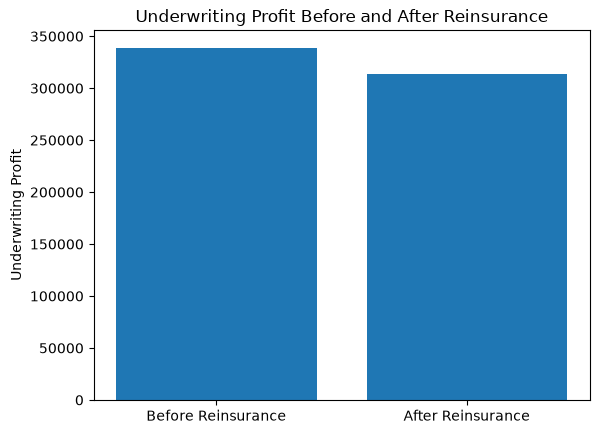

In [33]:
# Create labels for the two profit values.
profit_labels = [
    "Before Reinsurance",
    "After Reinsurance"
]

# Store the corresponding profit values.
profit_values = [
    underwriting_profit,
    underwriting_profit_after_reinsurance
]

# Create the bar chart.
plt.bar(
    profit_labels,
    profit_values
)

# Add a title.
plt.title("Underwriting Profit Before and After Reinsurance")

# Label the vertical axis.
plt.ylabel("Underwriting Profit")

# Display the chart.
plt.show()

This section compares the insurer's maximum loss exposure before and after reinsurance.

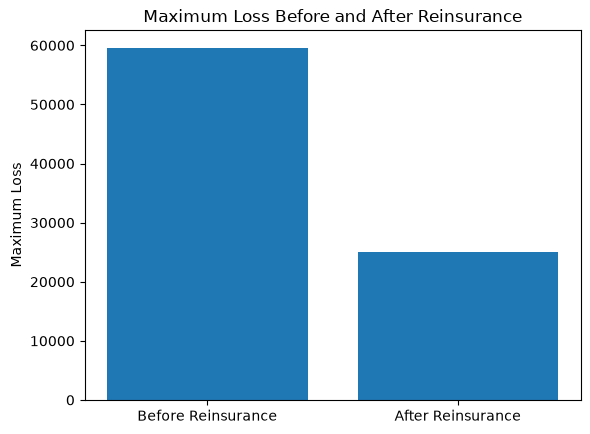

In [34]:
# Create labels for gross and net maximum losses.
loss_labels = [
    "Before Reinsurance",
    "After Reinsurance"
]

# Store the maximum loss values.
loss_values = [
    largest_gross_claim,
    largest_net_claim
]

# Create the bar chart.
plt.bar(
    loss_labels,
    loss_values
)

# Add a title.
plt.title("Maximum Loss Before and After Reinsurance")

# Label the vertical axis.
plt.ylabel("Maximum Loss")

# Display the chart.
plt.show()

This section compares the current indicated premium with next year's forecasted premium requirement.

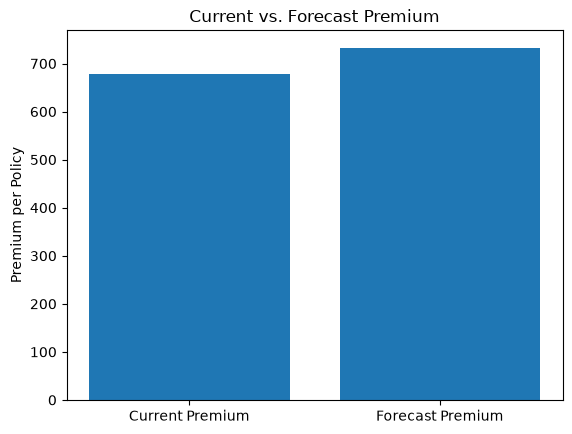

In [35]:
# Create labels for the current and forecast premiums.
premium_labels = [
    "Current Premium",
    "Forecast Premium"
]

# Store the corresponding premium values.
premium_values = [
    indicated_premium,
    forecast_premium
]

# Create the bar chart.
plt.bar(
    premium_labels,
    premium_values
)

# Add a title.
plt.title("Current vs. Forecast Premium")

# Label the vertical axis.
plt.ylabel("Premium per Policy")

# Display the chart.
plt.show()

## Conclusion

The simulated insurance portfolio produced an average claim severity of approximately $4,742 and a claim frequency of 10%.

Based on the modeled expense and profit assumptions, the indicated premium was approximately $677 per policy.

The portfolio generated an underwriting profit of approximately $338,727 before reinsurance.

The reserving model estimated case reserves of approximately 1.691 million dollars and IBNR reserves of approximately 237,109 dollars, resulting in total reserves of approximately 1.929 million dollars.

After adding excess-of-loss reinsurance with a 25,000 dollar retention, expected profit decreased to approximately $314,121, while the insurer's exposure to large individual claims was substantially reduced.

Using assumed increases in claim frequency and severity, the model projected a forecast premium of approximately $732 per policy and an 8.12% required premium increase for the following year.

Overall, the project demonstrates how pricing, plan-level analysis, reserving, reinsurance, profitability, and forecasting interact within an insurance portfolio.